In [ ]:
import os
import elevation

# Dictionary of 10 iconic volcanoes worldwide
# Each bounding box is exactly 0.20 degrees wide and 0.20 degrees tall, centered on the peak
VOLCANOES = {
    "Mt_Fujiyama_Japan":       (138.63, 35.26, 138.83, 35.46),
    "Mt_Vesuvius_Italy":       (14.33, 40.72, 14.53, 40.92),
    "Mt_Kilimanjaro_Tanzania": (37.25, -3.17, 37.45, -2.97),
    "Mt_St_Helens_USA":        (-122.29, 46.10, -122.09, 46.30),
    "Mt_Etna_Italy":           (14.90, 37.65, 15.10, 37.85),
    "Mt_Rainier_USA":          (-121.86, 46.75, -121.66, 46.95),
    "Mt_Kilauea_USA":          (-155.38, 19.32, -155.18, 19.52),
    "Mt_Popocatepetl_Mexico":  (-98.72, 18.92, -98.52, 19.12),
    "Mt_Krakatoa_Indonesia":   (105.32, -6.20, 105.52, -6.00),
    "Mt_Cotopaxi_Ecuador":     (-78.54, -0.78, -78.34, -0.58),
    "Mt_Mayon_Philippines":     (123.58, 13.16, 123.78, 13.36),  
    "Mt_Agung_Indonesia":       (115.41, -8.44, 115.61, -8.24),  
    "Mt_Pinatubo_Philippines":  (120.25, 15.04, 120.45, 15.24), 
    "Mt_Mauna_Loa_USA":         (-155.71, 19.38, -155.51, 19.58), 
    "Mt_Osorno_Chile":          (-72.59, -41.20, -72.39, -41.00), 
    "Mt_Merapi_Indonesia":      (110.34, -7.64, 110.54, -7.44),  
    "Mt_Teide_Spain":           (-16.74, 28.17, -16.54, 28.37), 
    "Mt_Shasta_USA":            (-122.30, 41.31, -122.10, 41.51), 
    "Mt_Shishaldin_Alaska":     (-164.05, 54.65, -163.85, 54.85),
    "Mt_Fuego_Guatemala":       (-90.98, 14.37, -90.78, 14.57)
}

# Create a dedicated directory for the TIF files to keep your workspace clean
output_dir = os.path.join(os.getcwd(), 'volcano_dems')
os.makedirs(output_dir, exist_ok=True)

print("Starting bulk DEM download for 10 volcanoes...")

for name, bounds in VOLCANOES.items():
    tif_filename = os.path.join(output_dir, f"{name}-DEM.tif")
    
    # Simple check to prevent re-downloading if you run the cell twice, or if you add any more volcanoes
    if not os.path.exists(tif_filename):
        print(f" -> Downloading {name.replace('_', ' ')}...")
        try:
            elevation.clip(bounds=bounds, output=tif_filename, max_download_tiles=10)
            elevation.clean()
        except Exception as e:
            print(f"Failed to download {name}: {e}")
    else:
        print(f" -> {name.replace('_', ' ')} DEM already exists. Skipping.")

print("\n All available volcano DEM files are ready in the 'volcano_dems' folder!")

# In the next cell, we generate a shaded relief representation of each volcano tile by normalizing '0' to the lowest point of elevation in that specific tile. The following cell DOES NOT represent true elevation of the peaks or regions

Scanning and processing 20 volcano DEM files...
Maximum Shared Net Vertical Relief: 13642 ft
Saving high-res 4x5 collage to Global_20_Volcano_Normalized_Collage.png...


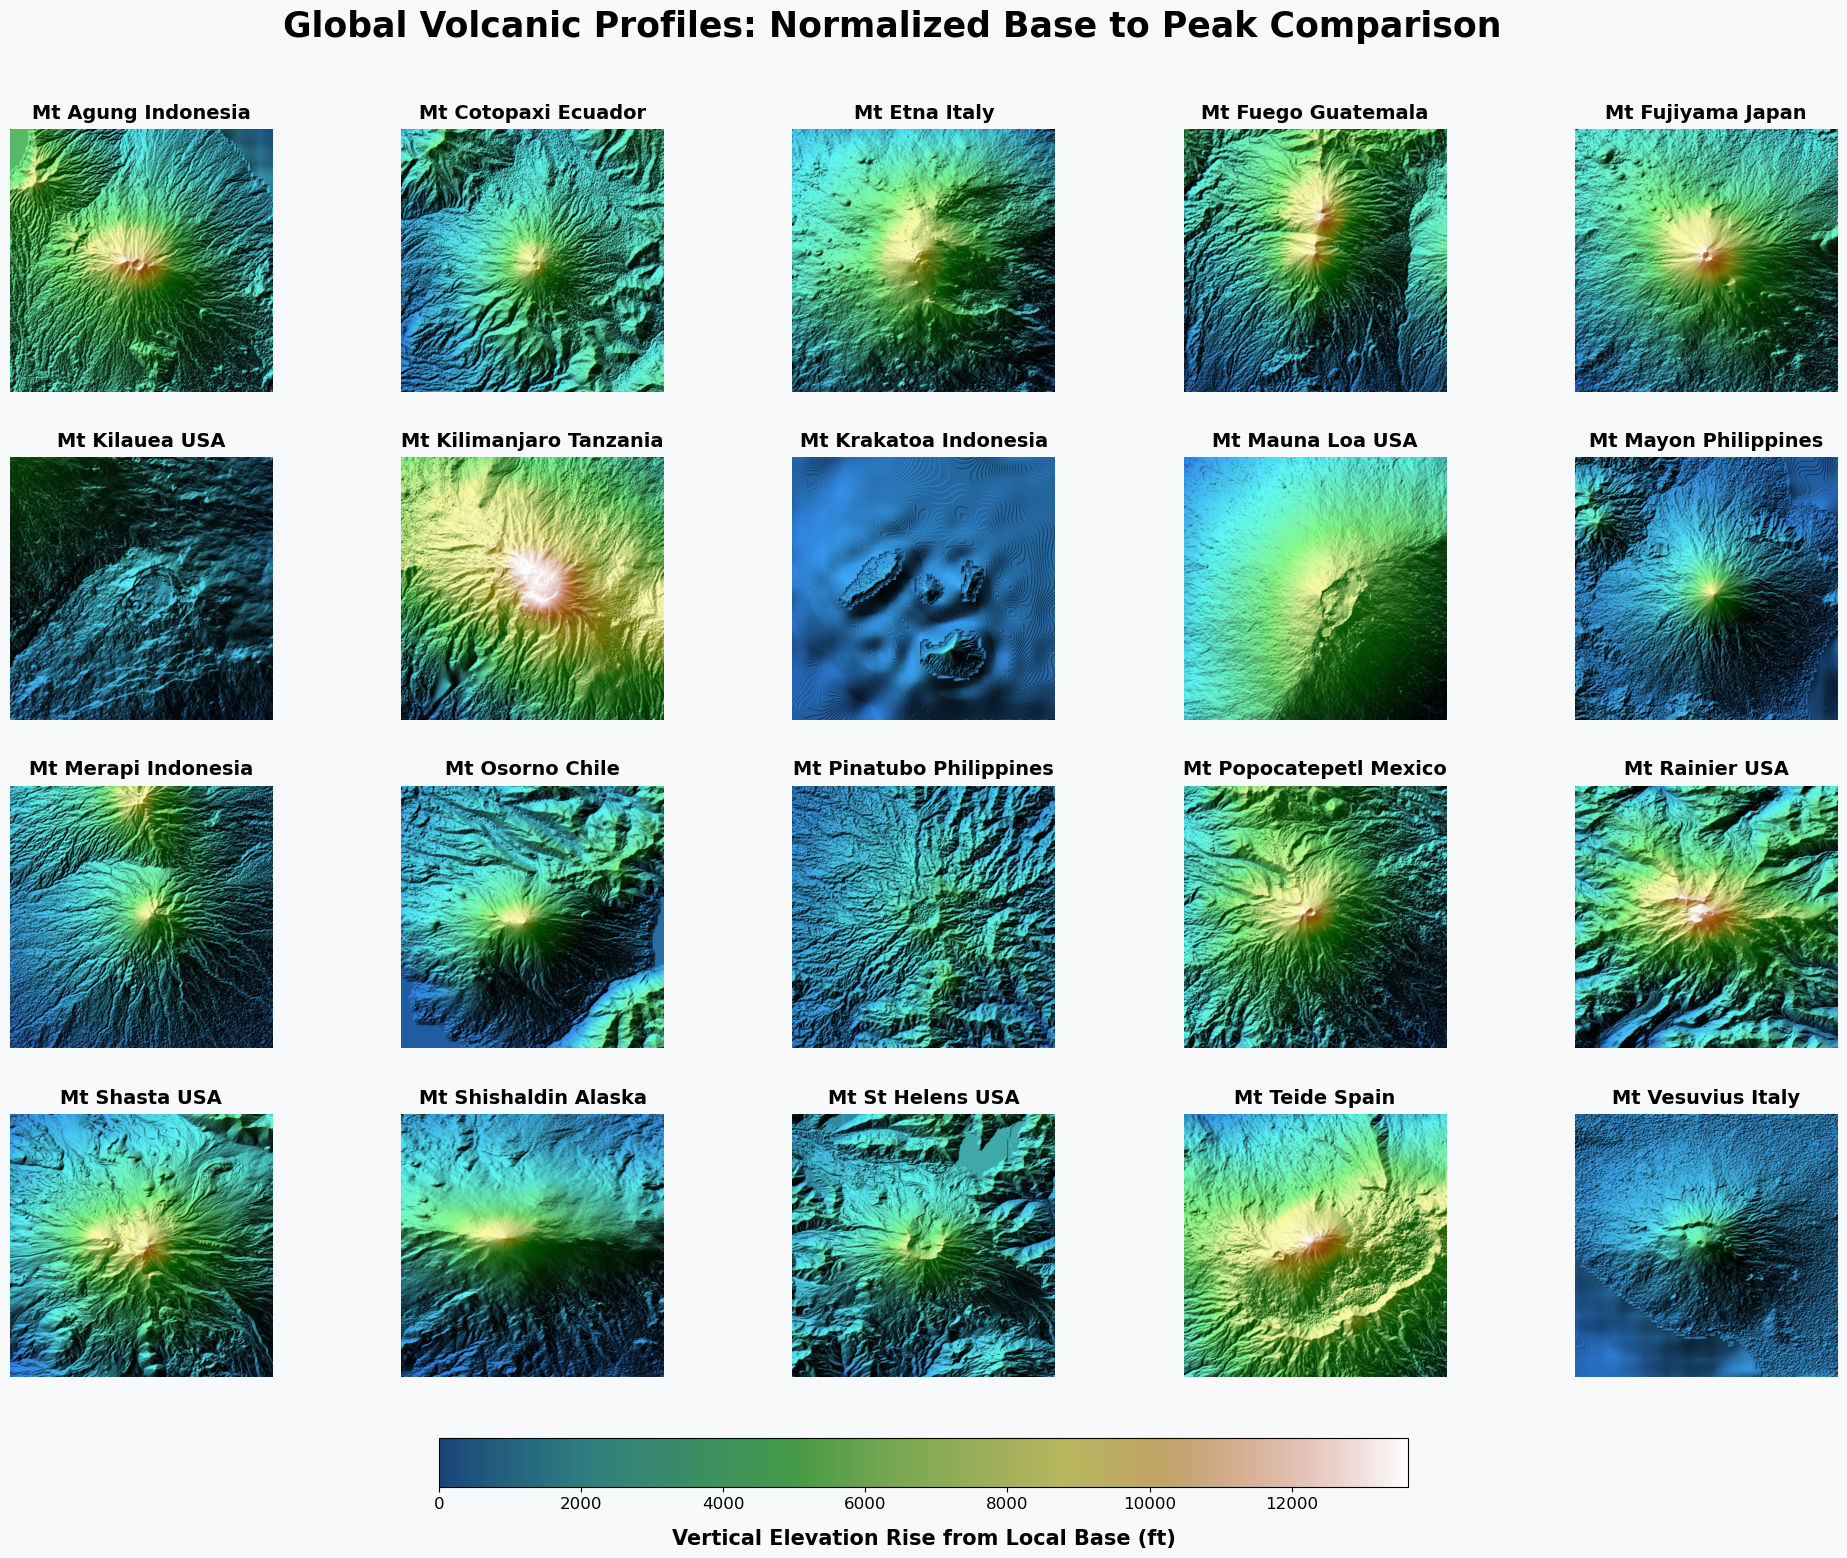

In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LightSource
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
DOWNSAMPLE_FACTOR = 1  # use 1 since tif files are tiny
DATA_DIR = os.path.join(os.getcwd(), 'volcano_dems')

# Automatically pull and sort all 20 downloaded files
tif_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.tif')])

volcano_data = []
global_max_relief = -np.inf  # Track the largest base-to-peak difference globally

print(f"Scanning and processing {len(tif_files)} volcano DEM files...")

# 1. LOAD, NORMALIZE BASELINE, AND TRACK GLOBAL MAX RELIEF
for filename in tif_files:
    v_name = filename.replace('-DEM.tif', '').replace('_', ' ')
    filepath = os.path.join(DATA_DIR, filename)
    
    with rasterio.open(filepath) as src:
        elev = src.read(1).astype('float32')
        elev[elev <= (src.nodata if src.nodata is not None else -9999)] = np.nan
        
        # Convert to feet
        elev_ft = elev * 3.28084
        elev_ft = elev_ft[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
        extent = plotting_extent(src)
        
        # Turn true data gaps/sea floor out to 0 before finding local baselines
        elev_ft = np.nan_to_num(elev_ft, nan=0.0)
        
        # Find the absolute baseline floor for *this specific tile*
        local_min = np.min(elev_ft)
        
        # Subtract the local baseline so this volcano's footprint starts flat at 0 ft
        local_relief = elev_ft - local_min
        
        # Track the tallest overall vertical rise across all 20 locations
        local_max = np.max(local_relief)
        if local_max > global_max_relief:
            global_max_relief = local_max
            
        volcano_data.append({
            'name': v_name,
            'relief_data': local_relief,
            'extent': extent
        })

print(f"Maximum Shared Net Vertical Relief: {global_max_relief:.0f} ft")

# 2. COLORMAP SETUP
# Clip 'gist_earth' to eliminate lower blues/teals, keeping terrain purely earthy
land_colors = plt.get_cmap('gist_earth')(np.linspace(0.15, 1.0, 256))
land_only_map = mcolors.LinearSegmentedColormap.from_list('land_only', land_colors)

# Shared normalization mapping from 0 to the tallest volcano's total relief
norm = plt.Normalize(vmin=0, vmax=global_max_relief)

# 3. LIGHTING SETUP
ls = LightSource(azdeg=315, altdeg=20)

# 4. COLLAGE PLOTTING (Expanded dynamically to 4 rows, 5 columns)
fig, axes = plt.subplots(4, 5, figsize=(25, 20), gridspec_kw={'wspace': 0.05, 'hspace': 0.25})
fig.patch.set_facecolor('#f8f9fa')
axes = axes.flatten()  # Flatten the 4x5 array to 1D for easy index looping

for i, v_dict in enumerate(volcano_data):
    ax = axes[i]
    
    # Calculate hillshading utilizing our global scale parameters
    rgb_shaded = ls.shade(v_dict['relief_data'], 
                          cmap=land_only_map, 
                          norm=norm,
                          blend_mode='overlay', 
                          vert_exag=1)
    
    # Render the topography image mapping
    ax.imshow(rgb_shaded, extent=v_dict['extent'], origin='upper', interpolation='bilinear', aspect='equal')
    ax.set_title(v_dict['name'], fontsize=14, fontweight='bold', pad=8)
    ax.axis('off')

# Safety check: if you happen to have fewer than 20 files, cleanly hide remaining subplots
for j in range(len(volcano_data), len(axes)):
    axes[j].axis('off')

# 5. UNIFIED COLORBAR (Positioned beautifully at the bottom of the 4-row stack)
sm = plt.cm.ScalarMappable(cmap=land_only_map, norm=norm)
sm._A = []
cb = fig.colorbar(sm, ax=axes.tolist(), shrink=0.5, pad=0.04, location='bottom')
cb.set_label('Vertical Elevation Rise from Local Base (ft)', fontsize=15, labelpad=12, fontweight='semibold')
cb.ax.tick_params(labelsize=12)

plt.suptitle("Global Volcanic Profiles: Normalized Base to Peak Comparison", fontsize=25, fontweight='bold', y=0.94)

# Save output high-res file
output_filename = "Global_20_Volcano_Normalized_Collage.png"
print(f"Saving high-res 4x5 collage to {output_filename}...")
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.4)
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.4,transparent=True)
plt.show()

# In the next cell, we represent each tile with actual elevation data and not normalizing each tile's minimum elevation to '0'

Scanning and processing 20 volcano DEM files on an absolute scale...
Shared Absolute Elevation Range: -1339 ft to 19311 ft
Saving high-res absolute 4x5 collage to Global_20_Volcano_Absolute_Collage.png...


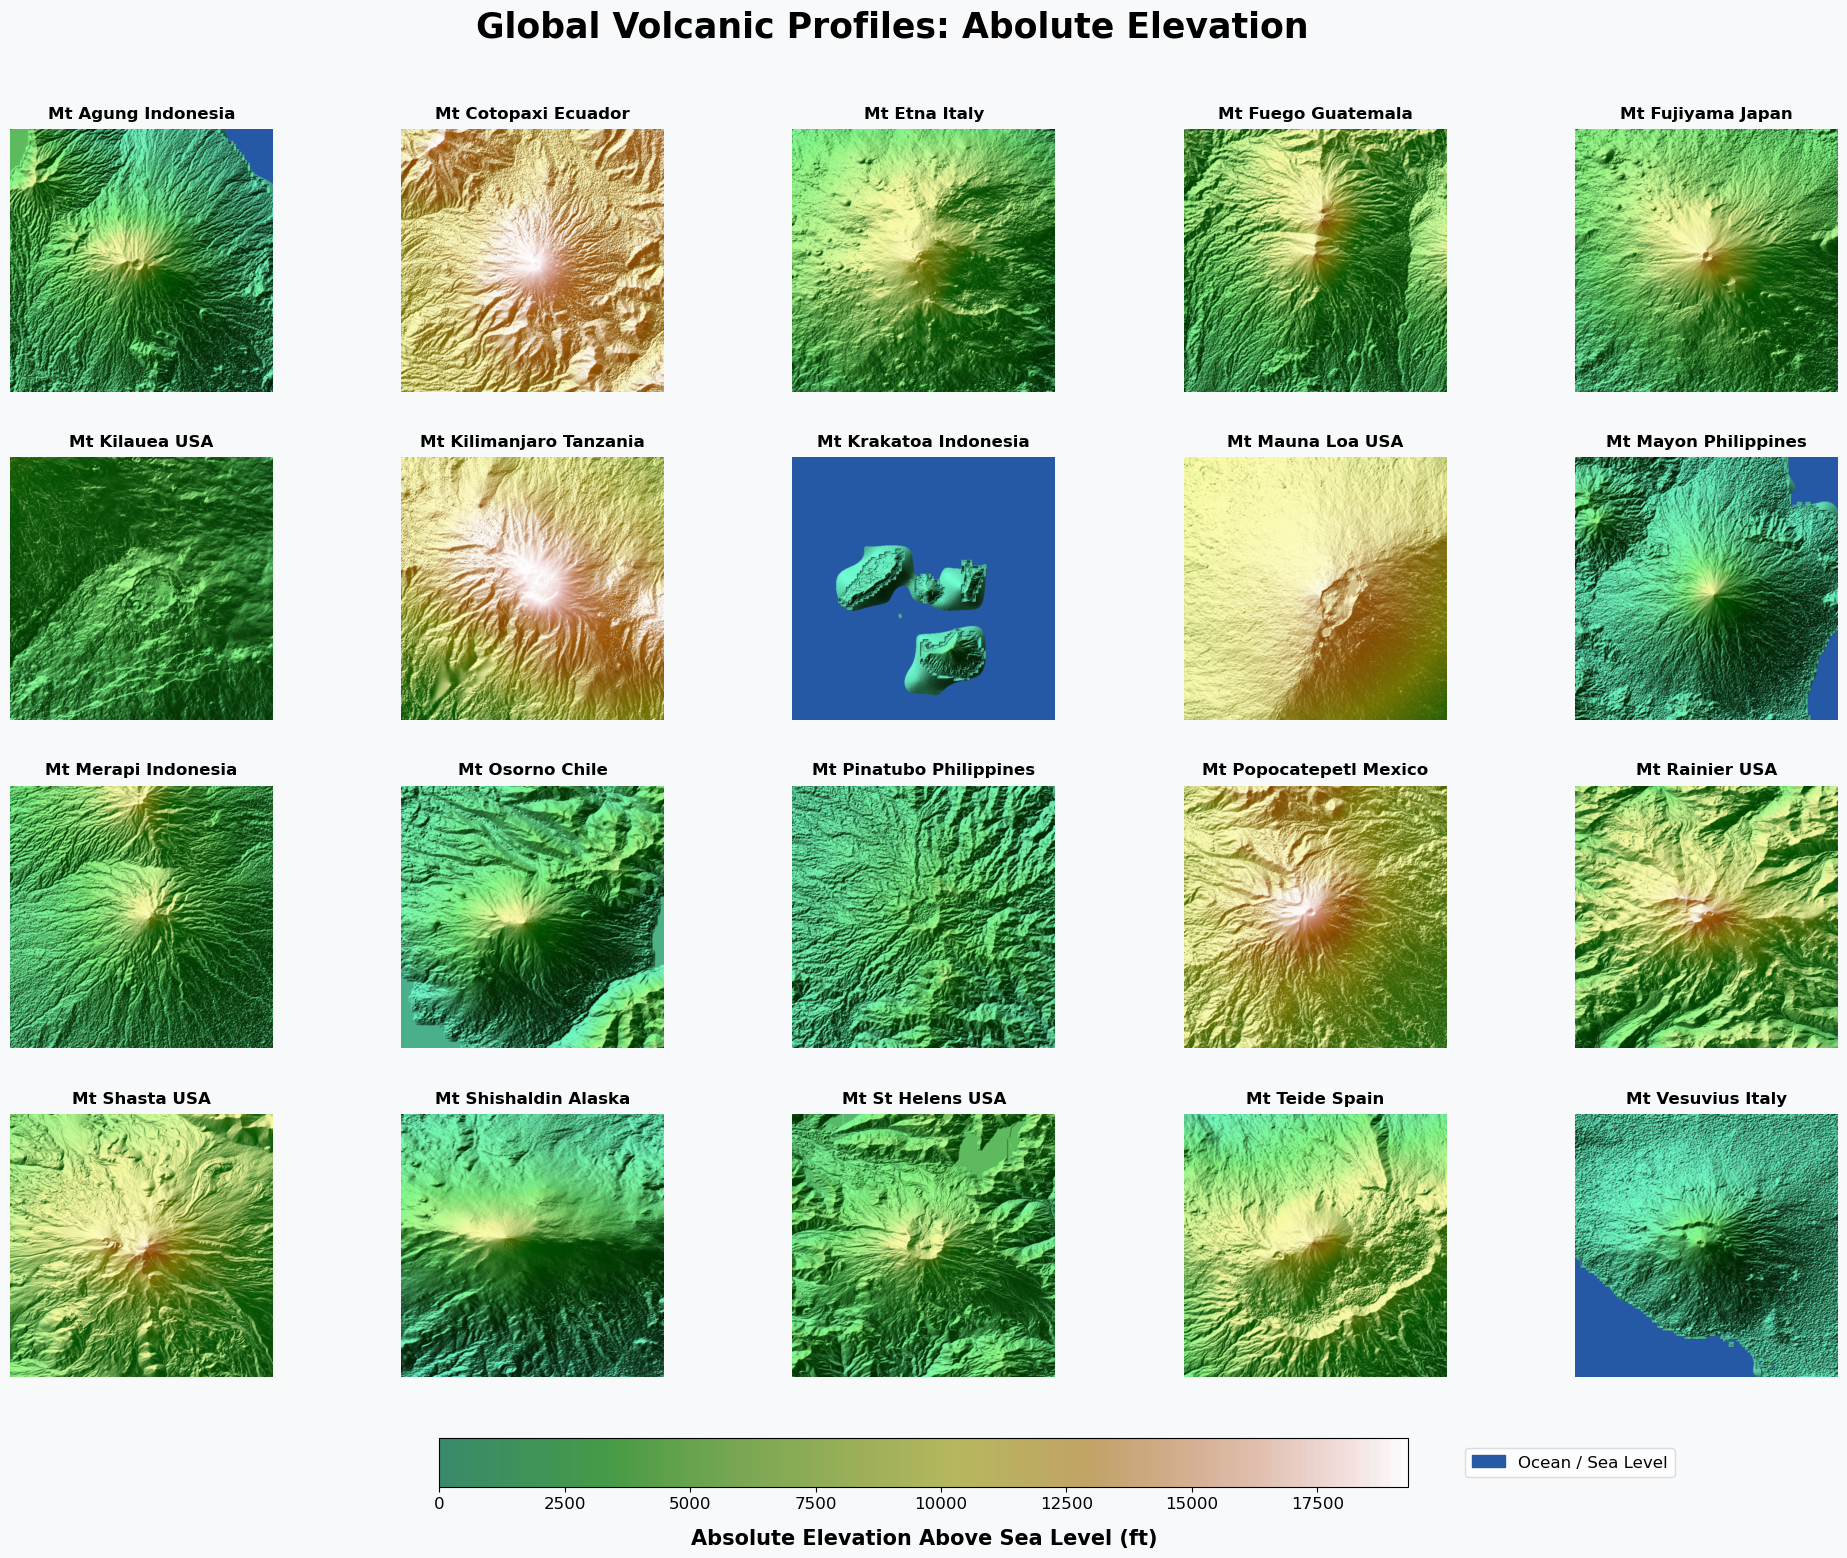

In [2]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LightSource
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
DOWNSAMPLE_FACTOR = 1  
DATA_DIR = os.path.join(os.getcwd(), 'volcano_dems')

# Automatically pull and sort all 20 downloaded files
tif_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.tif')])

volcano_data = []
global_min = np.inf
global_max = -np.inf

print(f"Scanning and processing {len(tif_files)} volcano DEM files on an absolute scale...")

# 1. LOAD AND TRACK GLOBAL ABSOLUTE LIMITS (NO SUBTRACTION)
for filename in tif_files:
    v_name = filename.replace('-DEM.tif', '').replace('_', ' ')
    filepath = os.path.join(DATA_DIR, filename)
    
    with rasterio.open(filepath) as src:
        elev = src.read(1).astype('float32')
        elev[elev <= (src.nodata if src.nodata is not None else -9999)] = np.nan
        
        # Convert to feet
        elev_ft = elev * 3.28084
        elev_ft = elev_ft[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
        extent = plotting_extent(src)
        
        # Clean true data gaps/sea floor out explicitly to 0 ft
        elev_ft = np.nan_to_num(elev_ft, nan=0.0)
        
        # Track absolute minimum and maximum boundaries globally
        if len(elev_ft) > 0:
            global_min = min(global_min, np.min(elev_ft))
            global_max = max(global_max, np.max(elev_ft))
            
        volcano_data.append({
            'name': v_name,
            'elevation_data': elev_ft,
            'extent': extent
        })

print(f"Shared Absolute Elevation Range: {global_min:.0f} ft to {global_max:.0f} ft")

# 2. COLORMAP SETUP (Strictly Terrestrial Greens to White)
# Slicing from 0.25 to 1.0 purges the native blues/teals from gist_earth completely
land_colors = plt.get_cmap('gist_earth')(np.linspace(0.35, 1.0, 256))
pure_green_land_map = mcolors.LinearSegmentedColormap.from_list('pure_green_land', land_colors)

# Flat ocean block vector color
ocean_blue = np.array([0.15, 0.35, 0.65, 1.0])  

# Continuous absolute normalization spanning from 0 ft up to the highest point
norm = plt.Normalize(vmin=0, vmax=global_max)

# 3. LIGHTING SETUP
ls = LightSource(azdeg=315, altdeg=20)

# 4. COLLAGE PLOTTING (4 rows, 5 columns)
fig, axes = plt.subplots(4, 5, figsize=(25, 20), gridspec_kw={'wspace': 0.05, 'hspace': 0.25})
fig.patch.set_facecolor('#f8f9fa')
axes = axes.flatten()  # Flatten array to 1D for straightforward index looping

for i, v_dict in enumerate(volcano_data):
    ax = axes[i]
    
    # Generate hillshading across absolute elevation arrays using the pure-green map
    rgb_shaded = ls.shade(v_dict['elevation_data'], 
                          cmap=pure_green_land_map, 
                          norm=norm,
                          blend_mode='overlay', 
                          vert_exag=1)
    
    # Identify pixels at or below sea level
    sea_level_mask = (v_dict['elevation_data'] <= 2.0)
    
    # Overwrite the flat sea surface pixels with solid ocean blue
    rgb_shaded[sea_level_mask] = ocean_blue
        
    ax.imshow(rgb_shaded, extent=v_dict['extent'], origin='upper', interpolation='bilinear', aspect='equal')
    ax.set_title(v_dict['name'], fontsize=12, fontweight='bold', pad=8)
    ax.axis('off')

# Cleanly hide remaining subplots if you have fewer than 20 files
for j in range(len(volcano_data), len(axes)):
    axes[j].axis('off')

# 5. TERRESTRIAL-ONLY COLORBAR (Zero Blue Present, starts exactly at pure valley green)
sm = plt.cm.ScalarMappable(cmap=pure_green_land_map, norm=norm)
sm._A = []
cb = fig.colorbar(sm, ax=axes.tolist(), shrink=0.5, pad=0.04, location='bottom')
cb.set_label('Absolute Elevation Above Sea Level (ft)', fontsize=15, labelpad=12, fontweight='semibold')
cb.ax.tick_params(labelsize=12)

# 6. EXPLICIT OCEAN INDICATOR KEY
ocean_patch = mpatches.Patch(color=ocean_blue, label='Ocean / Sea Level')
cb.ax.legend(handles=[ocean_patch], loc='center left', bbox_to_anchor=(1.05, 0.5),
             frameon=True, facecolor='#ffffff', edgecolor='#d1d5db', fontsize=12)

plt.suptitle("Global Volcanic Profiles: Abolute Elevation", fontsize=25, fontweight='bold', y=0.94)

# Save output high-res file
output_filename = "Global_20_Volcano_Absolute_Collage.png"
print(f"Saving high-res absolute 4x5 collage to {output_filename}...")
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.4)
# plt.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.4,transparent=True)
plt.show()